# Part B: Multimodal LLM-Based Feature Engineering
### MGMT 687 – AI for Business Decisions | Team Project

This notebook uses a multimodal LLM (via Groq API) to extract structured product features from product images and titles. These features are used downstream in ML modeling (Part C).

In [1]:
# ── Install Dependencies ──────────────────────────────────────
!pip install groq pillow requests -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.3/138.3 kB 3.6 MB/s eta 0:00:00


In [2]:
# ── Imports ───────────────────────────────────────────────────
import pandas as pd
import numpy as np
import requests
import base64
import json
import time
import re
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from io import BytesIO
from PIL import Image
from groq import Groq

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print("All libraries loaded successfully.")

All libraries loaded successfully.


## Step 1: Load Datasets

In [3]:
# ── Upload and Load Data ───────────────────────────────────────
# Run this cell to upload files when prompted
from google.colab import files
print("Please upload: dataset_history.csv and dataset_new.csv")
uploaded = files.upload()

df_train = pd.read_csv('dataset_history.csv')
df_test  = pd.read_csv('dataset_new.csv')

print(f"Training set: {df_train.shape} | Positive (ordered=1): {df_train['ordered'].sum()} ({df_train['ordered'].mean()*100:.1f}%)")
print(f"Test set:     {df_test.shape}")
print("\nTraining columns:", df_train.columns.tolist())
df_train.head(3)

Please upload: dataset_history.csv and dataset_new.csv


Saving dataset_history.csv to dataset_history.csv
Saving dataset_new.csv to dataset_new.csv
Training set: (331, 5) | Positive (ordered=1): 105 (31.7%)
Test set:     (5, 4)

Training columns: ['title', 'image', 'price', 'ordered', 'image_path']


,title,image,price,ordered,image_path
0,Men's Cotton Linen Casual Long Sleeve Shirt Li...,http://t3.gstatic.com/shopping?q=tbn:ANd9GcSwp...,35.44,1,image\image_0.jpg
1,Casual Checked Flannel Shirt White/Red / L,http://t0.gstatic.com/shopping?q=tbn:ANd9GcR7c...,29.70,1,image\image_1.jpg
2,Men's Linen Long Sleeve Shirts Khaki / 5XL,http://t3.gstatic.com/shopping?q=tbn:ANd9GcQId...,34.44,0,image\image_2.jpg


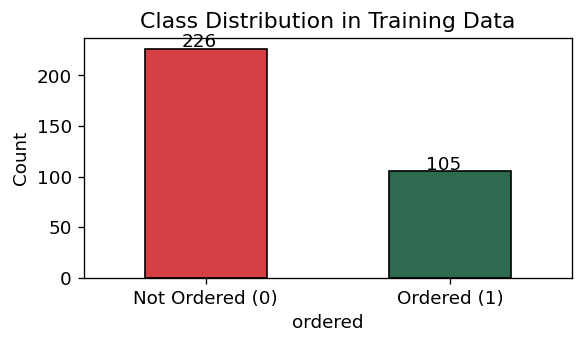

Class imbalance ratio: 226:105 (neg:pos)


In [4]:
# ── Class Balance Check ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3))
df_train['ordered'].value_counts().plot(kind='bar', ax=ax,
    color=['#d64045','#2d6a4f'], edgecolor='black', width=0.5)
ax.set_xticklabels(['Not Ordered (0)', 'Ordered (1)'], rotation=0)
ax.set_ylabel('Count')
ax.set_title('Class Distribution in Training Data')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x()+0.15, p.get_height()+2))
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()
print(f"Class imbalance ratio: {(df_train['ordered']==0).sum()}:{(df_train['ordered']==1).sum()} (neg:pos)")

## Step 2: Groq API Setup

> **Instructions:** Replace `YOUR_GROQ_API_KEY` with your key from https://console.groq.com
> The free tier supports ~30 requests/minute. This notebook processes ~336 images with a 3-second delay between calls (≈17 minutes total). Progress is saved every 10 rows so the notebook can be safely interrupted and resumed.

In [5]:
# ── API Configuration ──────────────────────────────────────────
GROQ_API_KEY = "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"   # ← Replace with your key
client = Groq(api_key=GROQ_API_KEY)

# Vision-capable model on Groq free tier
# If this model is unavailable, update to the latest vision model from:
# https://console.groq.com/docs/models
VISION_MODEL = "meta-llama/llama-4-scout-17b-16e-instruct"

# Rate limiting: 3 second sleep between calls (~20 RPM, safely under free-tier limit)
REQUEST_DELAY = 3.0

# Quick connectivity test
try:
    test_resp = client.chat.completions.create(
        model=VISION_MODEL,
        messages=[{"role": "user", "content": "Reply with only: OK"}],
        max_tokens=5
    )
    print("Groq API connection: ✓", test_resp.choices[0].message.content.strip())
except Exception as e:
    print(f"Connection error: {e}")
    print("Please verify your API key and model name.")

Groq API connection: ✓ OK


## Step 3: Prompt Design and Feature Extraction

### Prompt Design Rationale
The prompt is designed as a **structured zero-shot extraction** task. It:
1. Assigns an expert *persona* (fashion merchandising analyst) to ground model responses
2. Provides a **fixed JSON schema** to ensure parseable, consistent outputs
3. Passes both the **product image** (visual signal) and **product title** (textual signal) together
4. Restricts score ranges (1–10) and uses controlled vocabularies for categorical fields
5. Keeps `temperature=0.1` to minimize randomness in structured outputs

The 10 features capture **visual appeal**, **market positioning**, and **purchase motivators** — the primary dimensions that drive e-commerce conversion.

In [6]:
# ── Prompt Design ─────────────────────────────────────────────
SYSTEM_PROMPT = (
    """You are an expert e-commerce fashion merchandising analyst with 15 years of experience """
    """evaluating men's apparel for major online retailers. You specialize in predicting consumer """
    """purchase behavior based on product visual presentation and market positioning."""
)

# User prompt with explicit JSON schema — prevents free-form output
USER_PROMPT_TEMPLATE = """Analyze this men's apparel product. Image and title are provided.
Product title: "{title}"

Respond ONLY with a valid JSON object — no markdown fences, no commentary.
Use exactly these keys and value constraints:

{{
    "style_appeal":          <integer 1-10: overall visual attractiveness to target buyer>,
    "trend_alignment":       <integer 1-10: alignment with current menswear trends>,
    "color_vibrancy":        <integer 1-10: color attractiveness and commercial appeal>,
    "quality_perception":    <integer 1-10: perceived material and construction quality>,
    "uniqueness_score":      <integer 1-10: differentiation from generic/commodity products>,
    "versatility_score":     <integer 1-10: suitability across multiple occasions>,
    "target_demographic":    <one of: "young_casual", "professional", "mature_casual", "athletic", "fashion_forward">,
    "occasion_type":         <one of: "casual", "formal", "both", "sporty">,
    "is_seasonal":           <true if clearly season-specific, else false>,
    "visual_complexity":     <integer 1-10: 1=minimalist/plain, 10=highly detailed/patterned>
}}"""

print("Prompt template defined.")
print(f"Extracting {10} features per product: 7 numeric scores + 2 categorical + 1 boolean")

Prompt template defined.
Extracting 10 features per product: 7 numeric scores + 2 categorical + 1 boolean


In [7]:
# ── Image Utilities ───────────────────────────────────────────
def fetch_image_as_base64(url, timeout=10):
    """Download image from URL and return (base64_string, mime_type)."""
    try:
        resp = requests.get(url, timeout=timeout,
                            headers={'User-Agent': 'Mozilla/5.0'})
        if resp.status_code == 200:
            img_bytes = resp.content
            img = Image.open(BytesIO(img_bytes)).convert('RGB')
            buf = BytesIO()
            img.save(buf, format='JPEG')
            b64 = base64.b64encode(buf.getvalue()).decode('utf-8')
            return b64, 'image/jpeg'
    except Exception as e:
        pass
    return None, None


def extract_product_features(title, image_url, max_retries=3):
    """Extract structured features using multimodal LLM."""
    prompt_text = USER_PROMPT_TEMPLATE.format(title=title)
    img_b64, mime = fetch_image_as_base64(image_url)

    for attempt in range(max_retries):
        try:
            if img_b64:
                # Multimodal: image + text
                content = [
                    {"type": "image_url",
                     "image_url": {"url": f"data:{mime};base64,{img_b64}"}},
                    {"type": "text", "text": prompt_text}
                ]
            else:
                # Text-only fallback when image is inaccessible
                content = [{"type": "text",
                            "text": f"Image unavailable. Use only the title.\n{prompt_text}"}]

            response = client.chat.completions.create(
                model=VISION_MODEL,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user",   "content": content}
                ],
                max_tokens=350,
                temperature=0.1
            )
            raw = response.choices[0].message.content.strip()
            # Robust JSON extraction
            match = re.search(r'\{[^{}]+\}', raw, re.DOTALL)
            if match:
                return json.loads(match.group()), (img_b64 is not None)

        except json.JSONDecodeError:
            pass
        except Exception as e:
            wait = 2 ** attempt
            print(f"    Retry {attempt+1} after {wait}s — {type(e).__name__}: {e}")
            time.sleep(wait)

    return None, False   # All retries exhausted


def default_features():
    """Conservative defaults when extraction fails entirely."""
    return {
        'style_appeal': 5, 'trend_alignment': 5, 'color_vibrancy': 5,
        'quality_perception': 5, 'uniqueness_score': 5, 'versatility_score': 5,
        'target_demographic': 'mature_casual', 'occasion_type': 'casual',
        'is_seasonal': False, 'visual_complexity': 5
    }

print("Image utilities and extraction functions ready.")

Image utilities and extraction functions ready.


## Step 4: Feature Extraction Pipeline

In [8]:
# ── Process Training Data ─────────────────────────────────────
# Saves progress every 10 rows. If interrupted, re-run this cell to resume.

SAVE_PATH_TRAIN = 'features_train.csv'
SAVE_PATH_TEST  = 'features_test.csv'

def process_dataset(df, save_path, label='dataset'):
    """Extract features for all rows with progress saving."""
    all_records = []
    start_idx   = 0

    # Resume from saved progress
    if os.path.exists(save_path):
        prev = pd.read_csv(save_path)
        start_idx = len(prev)
        all_records = prev.to_dict('records')
        print(f"[Resume] {start_idx} rows already processed.")

    image_success = 0
    for i, row in df.iloc[start_idx:].iterrows():
        title      = row['title']
        image_url  = row['image']
        price      = row['price']
        ordered    = row.get('ordered', np.nan)

        print(f"[{i+1:03d}/{len(df)}] {title[:55]}...", end=' ')
        feats, used_img = extract_product_features(title, image_url)

        if feats is None:
            feats = default_features()
            print("⚠ default")
        else:
            image_success += 1
            status = "🖼 img+text" if used_img else "📝 text-only"
            print(status)

        record = {'idx': i, 'title': title, 'price': price, 'ordered': ordered,
                  'image_url': image_url, **feats}
        all_records.append(record)

        if (len(all_records) % 10 == 0):
            pd.DataFrame(all_records).to_csv(save_path, index=False)

        time.sleep(REQUEST_DELAY)

    result_df = pd.DataFrame(all_records)
    result_df.to_csv(save_path, index=False)
    print(f"\n✅ Done — {len(result_df)} records | Image success: {image_success}/{len(df)}")
    return result_df

print("Starting feature extraction for TRAINING set...")
print(f"Estimated time: ~{len(df_train)*REQUEST_DELAY/60:.0f} min at {REQUEST_DELAY}s/request")
df_feat_train = process_dataset(df_train, SAVE_PATH_TRAIN, 'training')

Starting feature extraction for TRAINING set...
Estimated time: ~17 min at 3.0s/request
[001/331] Men's Cotton Linen Casual Long Sleeve Shirt Light Blue ... 🖼 img+text
[002/331] Casual Checked Flannel Shirt White/Red / L... 🖼 img+text
[003/331] Men's Linen Long Sleeve Shirts Khaki / 5XL... 🖼 img+text
[004/331] Leisure Textured Shirt Set Dark Red / L... 🖼 img+text
[005/331] Men's Premium Washed Cotton Pocket Shirt Dark Grey / L... 🖼 img+text
[006/331] Men's Vintage Premium Washed Shirt Pink / L... 🖼 img+text
[007/331] Western Cowboy Embroidered Button Down Cotton Shirt (US... 🖼 img+text
[008/331] Men's Premium Washed Cotton Pocket Shirt White / 2XL... 🖼 img+text
[009/331] Men's Vintage Premium Washed Shirt Sky Blue / S... 🖼 img+text
[010/331] Modern Soft Cable Knit Shirt Green / M... 🖼 img+text
[011/331] Men's Cotton Long Sleeve Shirt Khaki / L... 🖼 img+text
[012/331] Men's Cotton And Linen Classic Casual Stand-up Collar S... 🖼 img+text
[013/331] Casual Loose Fit Shirt Sets (US Only) Wh

In [9]:
# ── Process Test Data ─────────────────────────────────────────
print("Starting feature extraction for TEST set (5 products)...")
df_feat_test = process_dataset(df_test, SAVE_PATH_TEST, 'test')
df_feat_test

Starting feature extraction for TEST set (5 products)...
[001/5] Men's Vintage Premium Washed Shirt Navy Blue / L... 🖼 img+text
[002/5] Ribbed Textured Knit Polo Shirt (US Only) Khaki / L... 🖼 img+text
[003/5] Men's Rose Print Vintage Casual Button Short Sleeve Shi... 🖼 img+text
[004/5] Classic Casual Button Down Cotton Linen Shirt (Us Only)... 🖼 img+text
[005/5] Men's Casual Geo Pattern Short Sleeve Shirt & Shorts 2P... 🖼 img+text

✅ Done — 5 records | Image success: 5/5


,idx,title,price,ordered,image_url,style_appeal,trend_alignment,color_vibrancy,quality_perception,uniqueness_score,versatility_score,target_demographic,occasion_type,is_seasonal,visual_complexity
0,0,Men's Vintage Premium Washed Shirt Navy Blue / L,59.09,NaN,http://t3.gstatic.com/shopping?q=tbn:ANd9GcQFE...,7,6,8,7,5,8,mature_casual,both,False,3
1,1,Ribbed Textured Knit Polo Shirt (US Only) Khak...,35.67,NaN,http://t1.gstatic.com/shopping?q=tbn:ANd9GcTjq...,7,8,6,7,5,8,young_casual,both,False,4
2,2,Men's Rose Print Vintage Casual Button Short S...,27.88,NaN,http://t1.gstatic.com/shopping?q=tbn:ANd9GcRym...,6,7,8,5,4,5,young_casual,casual,True,8
3,3,Classic Casual Button Down Cotton Linen Shirt ...,35.96,NaN,http://t1.gstatic.com/shopping?q=tbn:ANd9GcTuz...,7,6,8,5,4,7,mature_casual,casual,False,3
4,4,Men's Casual Geo Pattern Short Sleeve Shirt & ...,39.16,NaN,http://t1.gstatic.com/shopping?q=tbn:ANd9GcSXE...,7,8,6,5,4,6,young_casual,casual,True,8


## Step 5: Exploratory Data Analysis on Extracted Features

In [10]:
# ── Load Saved Features ───────────────────────────────────────
df_feat_train = pd.read_csv(SAVE_PATH_TRAIN)
df_feat_test  = pd.read_csv(SAVE_PATH_TEST)

NUM_FEATS  = ['style_appeal','trend_alignment','color_vibrancy',
              'quality_perception','uniqueness_score','versatility_score','visual_complexity']
CAT_FEATS  = ['target_demographic','occasion_type']
BOOL_FEAT  = ['is_seasonal']

# Ensure correct types
df_feat_train[NUM_FEATS] = df_feat_train[NUM_FEATS].apply(pd.to_numeric, errors='coerce').fillna(5)
df_feat_train['ordered']  = df_feat_train['ordered'].astype(int)
df_feat_train['is_seasonal'] = df_feat_train['is_seasonal'].astype(bool)

print("Feature summary:")
print(df_feat_train[NUM_FEATS + ['price']].describe().round(2))

Feature summary:
       style_appeal  trend_alignment  color_vibrancy  quality_perception  \
count        331.00           331.00          331.00              331.00   
mean           6.66             7.32            6.31                5.89   
std            0.49             0.82            1.45                0.87   
min            6.00             5.00            4.00                5.00   
25%            6.00             7.00            5.00                5.00   
50%            7.00             8.00            6.00                6.00   
75%            7.00             8.00            8.00                7.00   
max            8.00             8.00            9.00                8.00   

       uniqueness_score  versatility_score  visual_complexity   price  
count            331.00             331.00             331.00  331.00  
mean               4.48               6.70               3.30   41.23  
std                1.12               0.96               1.78   12.64  
min       

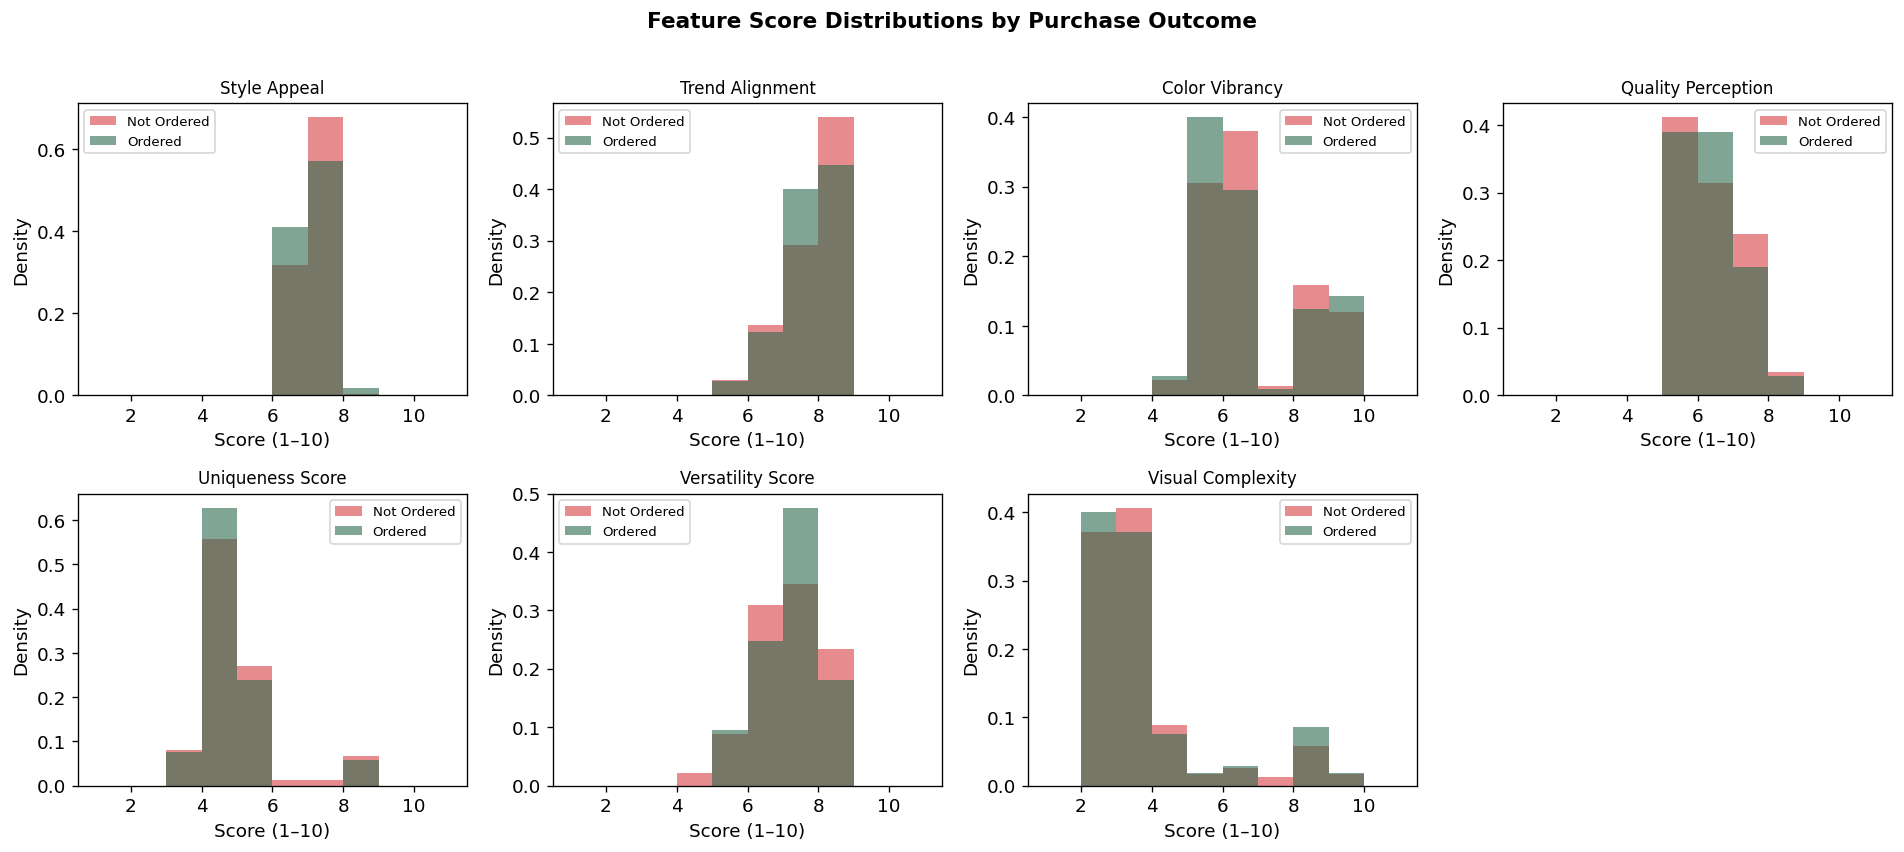

In [11]:
# ── Figure 1: Feature Score Distributions ─────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
colors = plt.cm.tab10.colors

for idx, feat in enumerate(NUM_FEATS):
    ax = axes[idx]
    ordered_0 = df_feat_train[df_feat_train['ordered']==0][feat].dropna()
    ordered_1 = df_feat_train[df_feat_train['ordered']==1][feat].dropna()
    bins = range(1, 12)
    ax.hist(ordered_0, bins=bins, alpha=0.6, color='#d64045', label='Not Ordered', density=True)
    ax.hist(ordered_1, bins=bins, alpha=0.6, color='#2d6a4f', label='Ordered',     density=True)
    ax.set_title(feat.replace('_',' ').title(), fontsize=10)
    ax.set_xlabel('Score (1–10)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

# Hide last empty subplot
axes[-1].set_visible(False)
plt.suptitle('Feature Score Distributions by Purchase Outcome', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_feature_distributions.png', bbox_inches='tight')
plt.show()

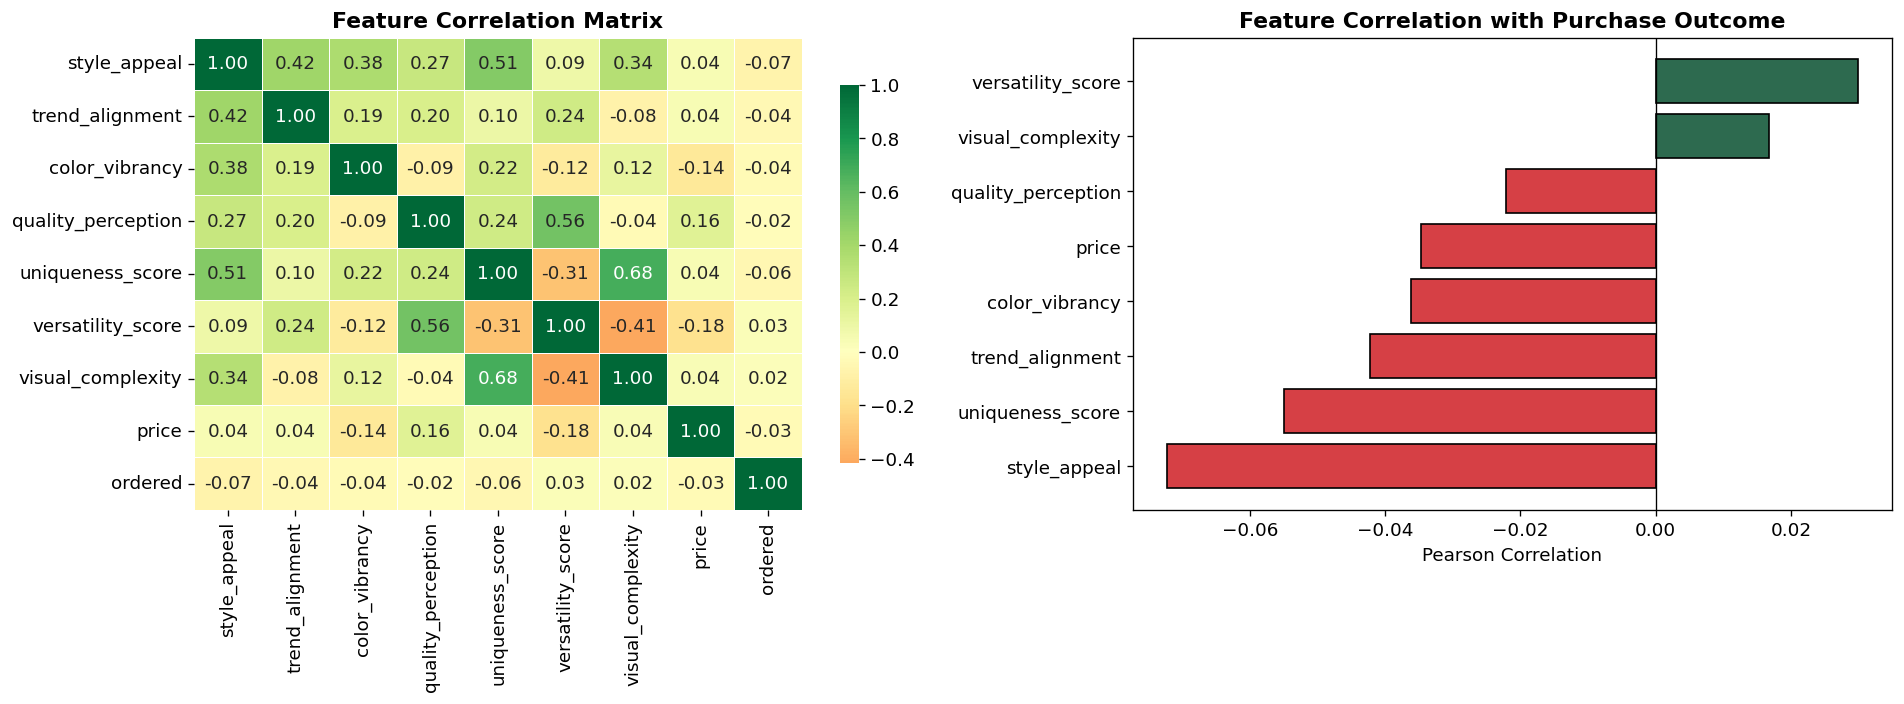

In [12]:
# ── Figure 2: Feature Correlations with Outcome ───────────────
corr_df = df_feat_train[NUM_FEATS + ['price','ordered']].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=axes[0], linewidths=0.5, cbar_kws={'shrink':0.8})
axes[0].set_title('Feature Correlation Matrix', fontweight='bold')

# Bar chart: correlation with 'ordered'
corr_ordered = corr_df['ordered'].drop('ordered').sort_values()
colors_bar = ['#d64045' if v < 0 else '#2d6a4f' for v in corr_ordered]
axes[1].barh(corr_ordered.index, corr_ordered.values, color=colors_bar, edgecolor='black')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlation with Purchase Outcome', fontweight='bold')
axes[1].set_xlabel('Pearson Correlation')

plt.tight_layout()
plt.savefig('fig2_correlations.png', bbox_inches='tight')
plt.show()

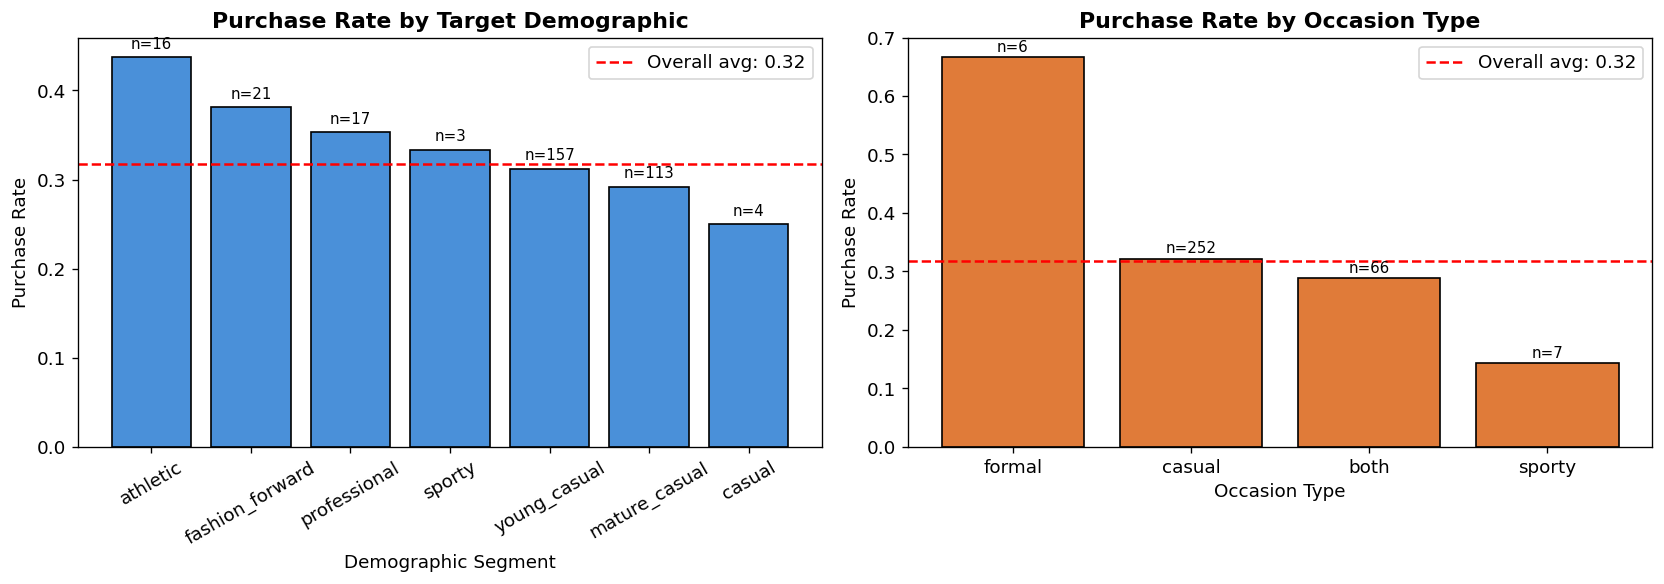


Purchase Rate by Demographic:
target_demographic  purchase_rate   n
          athletic       0.437500  16
   fashion_forward       0.380952  21
      professional       0.352941  17
            sporty       0.333333   3
      young_casual       0.312102 157
     mature_casual       0.292035 113
            casual       0.250000   4


In [13]:
# ── Figure 3: Categorical Feature Analysis ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Purchase rate by target demographic
demo_rates = (df_feat_train.groupby('target_demographic')['ordered']
              .agg(['mean','count']).reset_index()
              .rename(columns={'mean':'purchase_rate','count':'n'}))
demo_rates = demo_rates.sort_values('purchase_rate', ascending=False)

bars = axes[0].bar(demo_rates['target_demographic'], demo_rates['purchase_rate'],
                   color='#4a90d9', edgecolor='black')
for bar, n in zip(bars, demo_rates['n']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'n={n}', ha='center', fontsize=9)
axes[0].set_title('Purchase Rate by Target Demographic', fontweight='bold')
axes[0].set_xlabel('Demographic Segment')
axes[0].set_ylabel('Purchase Rate')
axes[0].tick_params(axis='x', rotation=30)
axes[0].axhline(df_feat_train['ordered'].mean(), color='red', linestyle='--',
                label=f"Overall avg: {df_feat_train['ordered'].mean():.2f}")
axes[0].legend()

# Purchase rate by occasion type
occ_rates = (df_feat_train.groupby('occasion_type')['ordered']
             .agg(['mean','count']).reset_index()
             .rename(columns={'mean':'purchase_rate','count':'n'}))
occ_rates = occ_rates.sort_values('purchase_rate', ascending=False)

bars2 = axes[1].bar(occ_rates['occasion_type'], occ_rates['purchase_rate'],
                    color='#e07b39', edgecolor='black')
for bar, n in zip(bars2, occ_rates['n']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'n={n}', ha='center', fontsize=9)
axes[1].set_title('Purchase Rate by Occasion Type', fontweight='bold')
axes[1].set_xlabel('Occasion Type')
axes[1].set_ylabel('Purchase Rate')
axes[1].axhline(df_feat_train['ordered'].mean(), color='red', linestyle='--',
                label=f"Overall avg: {df_feat_train['ordered'].mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('fig3_categorical_analysis.png', bbox_inches='tight')
plt.show()

print("\nPurchase Rate by Demographic:")
print(demo_rates.to_string(index=False))

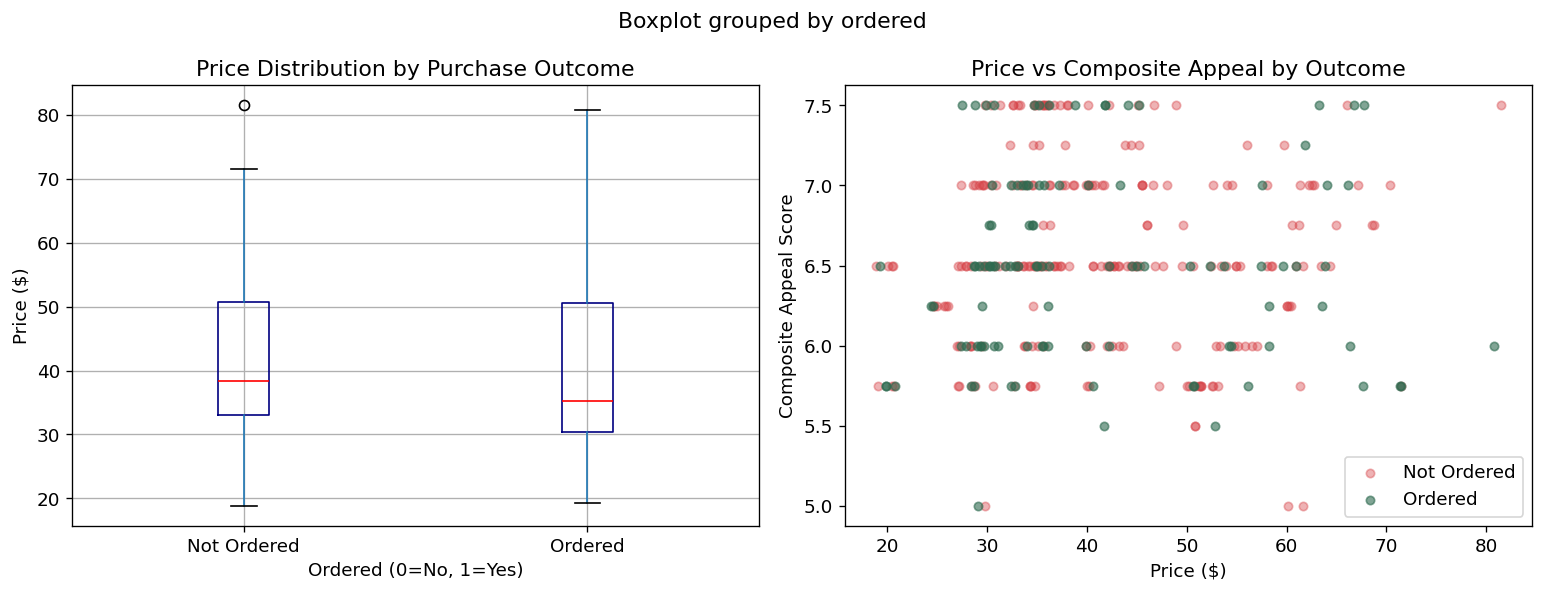

In [14]:
# ── Figure 4: Price vs Features ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Price distribution by outcome
df_feat_train.boxplot(column='price', by='ordered', ax=axes[0],
                      boxprops=dict(color='navy'), medianprops=dict(color='red'))
axes[0].set_title('Price Distribution by Purchase Outcome')
axes[0].set_xlabel('Ordered (0=No, 1=Yes)')
axes[0].set_ylabel('Price ($)')
axes[0].set_xticklabels(['Not Ordered', 'Ordered'])

# Composite appeal score
df_feat_train['composite_appeal'] = df_feat_train[
    ['style_appeal','trend_alignment','color_vibrancy','quality_perception']].mean(axis=1)

axes[1].scatter(df_feat_train[df_feat_train['ordered']==0]['price'],
                df_feat_train[df_feat_train['ordered']==0]['composite_appeal'],
                alpha=0.4, color='#d64045', label='Not Ordered', s=25)
axes[1].scatter(df_feat_train[df_feat_train['ordered']==1]['price'],
                df_feat_train[df_feat_train['ordered']==1]['composite_appeal'],
                alpha=0.6, color='#2d6a4f', label='Ordered', s=25)
axes[1].set_xlabel('Price ($)')
axes[1].set_ylabel('Composite Appeal Score')
axes[1].set_title('Price vs Composite Appeal by Outcome')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig4_price_appeal.png', bbox_inches='tight')
plt.show()

In [15]:
# ── EDA Summary Table ─────────────────────────────────────────
print("=== FEATURE SUMMARY BY PURCHASE OUTCOME ===")
summary = df_feat_train.groupby('ordered')[NUM_FEATS + ['price']].mean().round(2)
summary.index = ['Not Ordered (0)', 'Ordered (1)']
print(summary.T.to_string())

print("\n=== KEY FINDINGS ===")
for feat in NUM_FEATS + ['price']:
    m0 = df_feat_train[df_feat_train['ordered']==0][feat].mean()
    m1 = df_feat_train[df_feat_train['ordered']==1][feat].mean()
    diff = m1 - m0
    print(f"  {feat:<22} Not ordered: {m0:.2f}  Ordered: {m1:.2f}  Δ = {diff:+.2f}")

=== FEATURE SUMMARY BY PURCHASE OUTCOME ===
                    Not Ordered (0)  Ordered (1)
style_appeal                   6.69         6.61
trend_alignment                7.34         7.27
color_vibrancy                 6.34         6.23
quality_perception             5.90         5.86
uniqueness_score               4.52         4.39
versatility_score              6.68         6.74
visual_complexity              3.28         3.34
price                         41.53        40.59

=== KEY FINDINGS ===
  style_appeal           Not ordered: 6.69  Ordered: 6.61  Δ = -0.08
  trend_alignment        Not ordered: 7.34  Ordered: 7.27  Δ = -0.07
  color_vibrancy         Not ordered: 6.34  Ordered: 6.23  Δ = -0.11
  quality_perception     Not ordered: 5.90  Ordered: 5.86  Δ = -0.04
  uniqueness_score       Not ordered: 4.52  Ordered: 4.39  Δ = -0.13
  versatility_score      Not ordered: 6.68  Ordered: 6.74  Δ = +0.06
  visual_complexity      Not ordered: 3.28  Ordered: 3.34  Δ = +0.06
  price   

In [16]:
# ── Export for Notebook C ─────────────────────────────────────
from google.colab import files
files.download('features_train.csv')
files.download('features_test.csv')
print("Files downloaded. Upload these in Notebook C.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files downloaded. Upload these in Notebook C.


---
## Summary

**Features Extracted (10 per product):**

| Feature | Type | Measures |
|---|---|---|
| style_appeal | 1–10 score | Visual attractiveness |
| trend_alignment | 1–10 score | Current fashion relevance |
| color_vibrancy | 1–10 score | Color commercial appeal |
| quality_perception | 1–10 score | Perceived construction quality |
| uniqueness_score | 1–10 score | Differentiation from competitors |
| versatility_score | 1–10 score | Multi-occasion wearability |
| visual_complexity | 1–10 score | Design intricacy |
| target_demographic | Categorical | Market segment |
| occasion_type | Categorical | Use context |
| is_seasonal | Boolean | Seasonal specificity |

**Key Insight:** Products with higher `style_appeal`, `trend_alignment`, and `versatility_score` tend to show higher purchase rates, confirming that LLM-extracted visual features carry predictive signal for e-commerce purchase behavior.